In [1]:
library(edgeR)

Loading required package: limma



In [2]:
# load the data
countData <- read.table("combined_data.csv", header=TRUE, sep=",")
head(countData)

,gene_id,WT10R1,WT10R2,WT10R3,WT10R4,WT15R1,WT15R2,WT15R3,WT15R4,WT20R1,⋯,WT20R4,WT25R1,WT25R2,WT25R3,WT25R4,WT30R1,WT30R2,WT30R3,WT30R4,WT35R4
,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,Csa00382s010,203,270,153,130,275,244,174,142,101,⋯,46,88,45,120,130,43,21,34,37,0
2,Csa00382s020,1280,1552,1079,863,962,694,468,858,548,⋯,164,370,473,521,519,753,666,674,732,442
3,Csa00382s030,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
4,Csa00382s040,10,19,17,12,0,5,0,0,0,⋯,0,8,0,2,0,0,5,0,0,0
5,Csa00382s050,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
6,Csa00382s060,0,7,0,2,0,0,0,1,0,⋯,1,0,0,0,0,0,0,12,0,0


In [3]:
#help(mobData)
countDataGroups <- c("WT10", "WT10", "WT10", "WT10", "WT15", "WT15", "WT15", "WT15", "WT20", "WT20", "WT20", "WT20", "WT25", "WT25", "WT25", "WT25", "WT30", "WT30", "WT30", "WT30", "WT35")

In [4]:
d <- DGEList(counts=countData,group=factor(countDataGroups))
d

Setting first column of `counts` as gene annotation.



,WT10R1,WT10R2,WT10R3,WT10R4,WT15R1,WT15R2,WT15R3,WT15R4,WT20R1,WT20R2,⋯,WT20R4,WT25R1,WT25R2,WT25R3,WT25R4,WT30R1,WT30R2,WT30R3,WT30R4,WT35R4
1,203,270,153,130,275,244,174,142,101,56,⋯,46,88,45,120,130,43,21,34,37,0
2,1280,1552,1079,863,962,694,468,858,548,396,⋯,164,370,473,521,519,753,666,674,732,442
3,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
4,10,19,17,12,0,5,0,0,0,5,⋯,0,8,0,2,0,0,5,0,0,0
5,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
6,0,7,0,2,0,0,0,1,0,0,⋯,1,0,0,0,0,0,0,12,0,0
7,341,455,329,369,379,358,424,301,283,425,⋯,195,267,361,377,167,450,319,425,397,32
8,421,294,218,190,131,160,84,174,118,170,⋯,104,130,104,134,157,68,89,118,118,96
9,42,15,42,46,53,64,17,51,33,59,⋯,19,8,23,69,41,26,55,40,24,16
10,3596,3571,3707,3582,2336,2856,3363,3046,1583,1414,⋯,1111,1972,2456,2377,2878,5165,4696,6312,5626,10386


In [5]:
dim(d)

[1] 89402    21

In [6]:
d.full <- d # keep the old one in case we mess up
head(d$counts)

,WT10R1,WT10R2,WT10R3,WT10R4,WT15R1,WT15R2,WT15R3,WT15R4,WT20R1,WT20R2,⋯,WT20R4,WT25R1,WT25R2,WT25R3,WT25R4,WT30R1,WT30R2,WT30R3,WT30R4,WT35R4
1,203,270,153,130,275,244,174,142,101,56,⋯,46,88,45,120,130,43,21,34,37,0
2,1280,1552,1079,863,962,694,468,858,548,396,⋯,164,370,473,521,519,753,666,674,732,442
3,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
4,10,19,17,12,0,5,0,0,0,5,⋯,0,8,0,2,0,0,5,0,0,0
5,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
6,0,7,0,2,0,0,0,1,0,0,⋯,1,0,0,0,0,0,0,12,0,0


In [7]:
head(cpm(d))

,WT10R1,WT10R2,WT10R3,WT10R4,WT15R1,WT15R2,WT15R3,WT15R4,WT20R1,WT20R2,⋯,WT20R4,WT25R1,WT25R2,WT25R3,WT25R4,WT30R1,WT30R2,WT30R3,WT30R4,WT35R4
1,4.0008094,5.0438039,3.1453431,2.93954642,5.688472,5.0180674,3.456537,2.73148903,2.046077,1.1735053,⋯,1.25927942,2.2506249,0.9981522,2.29294532,2.855171,1.059039,0.5141511,0.7270576,0.7875092,0.00000
2,25.2267784,28.9925323,22.1818641,19.51406584,19.899310,14.2726999,9.296893,16.50434921,11.101487,8.2983592,⋯,4.48960488,9.4628546,10.4916889,9.95520426,11.398722,18.545503,16.3059346,14.4128483,15.5799111,12.15573
3,0.0000000,0.0000000,0.0000000,0.00000000,0.000000,0.0000000,0.000000,0.00000000,0.000000,0.0000000,⋯,0.00000000,0.0000000,0.0000000,0.00000000,0.000000,0.000000,0.0000000,0.0000000,0.0000000,0.00000
4,0.1970842,0.3549344,0.3494826,0.27134275,0.000000,0.1028293,0.000000,0.00000000,0.000000,0.1047773,⋯,0.00000000,0.2046023,0.0000000,0.03821576,0.000000,0.000000,0.1224169,0.0000000,0.0000000,0.00000
5,0.0000000,0.0000000,0.0000000,0.00000000,0.000000,0.0000000,0.000000,0.00000000,0.000000,0.0000000,⋯,0.00000000,0.0000000,0.0000000,0.00000000,0.000000,0.000000,0.0000000,0.0000000,0.0000000,0.00000
6,0.0000000,0.1307653,0.0000000,0.04522379,0.000000,0.0000000,0.000000,0.01923584,0.000000,0.0000000,⋯,0.02737564,0.0000000,0.0000000,0.00000000,0.000000,0.000000,0.0000000,0.2566086,0.0000000,0.00000


In [8]:
apply(d$counts, 2, sum) # total gene counts per sample

WT10R1   WT10R2   WT10R3   WT10R4   WT15R1   WT15R2   WT15R3   WT15R4 
50739733 53531026 48643342 44224510 48343384 48624297 50339399 51986297 
  WT20R1   WT20R2   WT20R3   WT20R4   WT25R1   WT25R2   WT25R3   WT25R4 
49362756 47720277 45592627 36528827 39100252 45083304 52334436 45531420 
  WT30R1   WT30R2   WT30R3   WT30R4   WT35R4 
40602834 40844025 46763831 46983580 36361459

In [9]:
keep <- rowSums(cpm(d)>100) >= 2
d <- d[keep,]
dim(d)

[1] 2101   21

In [10]:
d$samples$lib.size <- colSums(d$counts)
d$samples

,group,lib.size,norm.factors
,<fct>,<dbl>,<dbl>
WT10R1,WT10,19817206,1
WT10R2,WT10,20276099,1
WT10R3,WT10,19156252,1
WT10R4,WT10,17354747,1
WT15R1,WT15,23792936,1
WT15R2,WT15,24475243,1
WT15R3,WT15,25853253,1
WT15R4,WT15,25802678,1
WT20R1,WT20,30698283,1


In [11]:
d <- calcNormFactors(d)
d

,WT10R1,WT10R2,WT10R3,WT10R4,WT15R1,WT15R2,WT15R3,WT15R4,WT20R1,WT20R2,⋯,WT20R4,WT25R1,WT25R2,WT25R3,WT25R4,WT30R1,WT30R2,WT30R3,WT30R4,WT35R4
10,3596,3571,3707,3582,2336,2856,3363,3046,1583,1414,⋯,1111,1972,2456,2377,2878,5165,4696,6312,5626,10386
40,9883,11382,9476,8214,7256,5929,5699,7171,6485,6257,⋯,3617,6062,6964,8227,7455,3387,3875,4083,4178,609
95,7005,6779,7226,6812,6691,6861,7402,7077,3902,3988,⋯,3396,2955,3326,3824,2540,5800,5613,6358,6585,10580
117,5691,5020,6492,4909,16955,18249,19192,17735,21629,23657,⋯,21430,17027,20050,22486,13788,12846,12566,16580,15027,7864
118,15606,13324,14452,14643,3727,4047,5037,3751,237,244,⋯,95,19,38,21,0,14,21,36,34,0
154,12575,14624,12430,11690,11290,11261,10257,12164,14296,13266,⋯,8461,11814,13211,16253,13244,7375,8450,8342,9243,614
210,9960,9562,10011,9812,9120,10072,10979,11044,4890,5006,⋯,3923,4172,4850,5366,5794,9927,9405,11218,10559,27085
321,13946,12662,15644,12324,77137,81034,87584,91512,115999,124683,⋯,101926,91605,108322,114504,132374,75601,68381,94473,82864,52395
368,15758,17208,13979,12658,15727,14383,14220,14006,8072,5814,⋯,3791,2500,2692,4372,2879,534,617,620,520,0
610,5592,5938,4640,4253,6008,6529,5670,5815,3481,3420,⋯,1772,1509,1695,2131,1252,738,860,925,970,209


Note: the bcv method is now scheduled to be removed in a future release of edgeR.



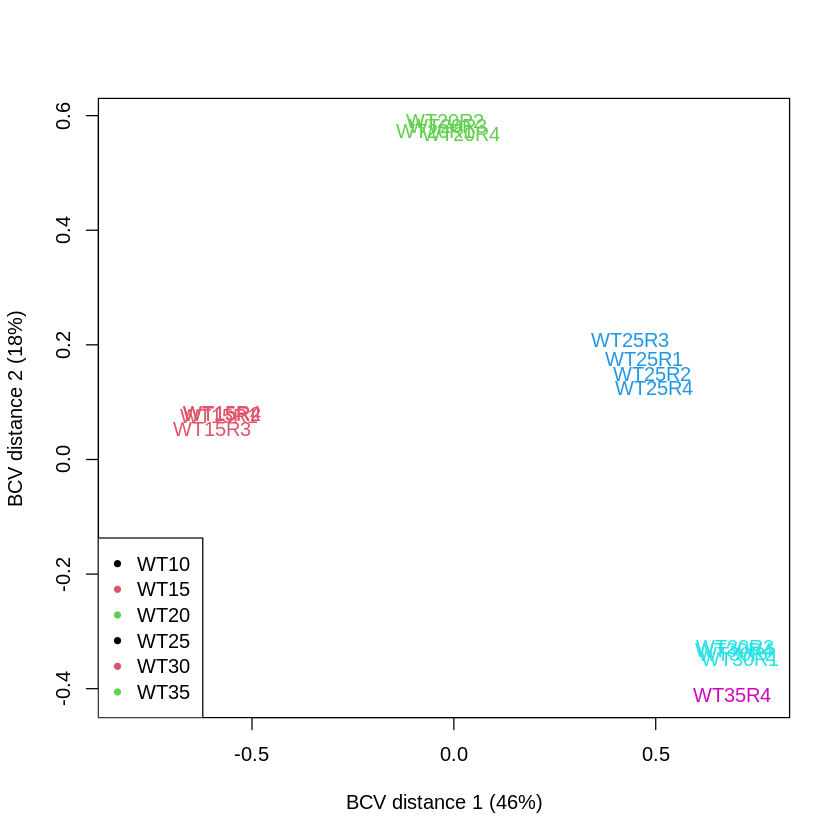

In [12]:
# method “logfc”, “logFC”, “bcv”, “BCV”
plotMDS(d, method="bcv", col=as.numeric(d$samples$group))
legend("bottomleft", as.character(unique(d$samples$group)), col=1:3, pch=20)

In [13]:
d1 <- estimateCommonDisp(d, verbose=T)

Disp = 0.01744 , BCV = 0.1321 


In [14]:
names(d1)

[1] "counts"            "samples"           "genes"            
[4] "common.dispersion" "pseudo.counts"     "pseudo.lib.size"  
[7] "AveLogCPM"

In [15]:
d1 <- estimateTagwiseDisp(d1)
names(d1)

[1] "counts"             "samples"            "genes"             
 [4] "common.dispersion"  "pseudo.counts"      "pseudo.lib.size"   
 [7] "AveLogCPM"          "prior.df"           "prior.n"           
[10] "tagwise.dispersion" "span"

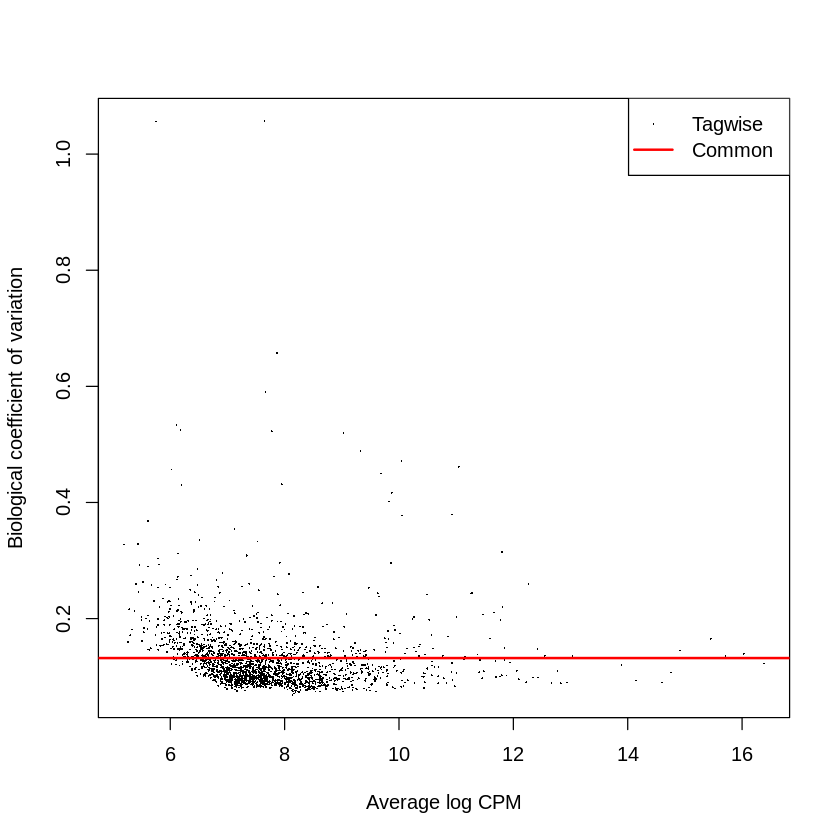

In [16]:
plotBCV(d1)

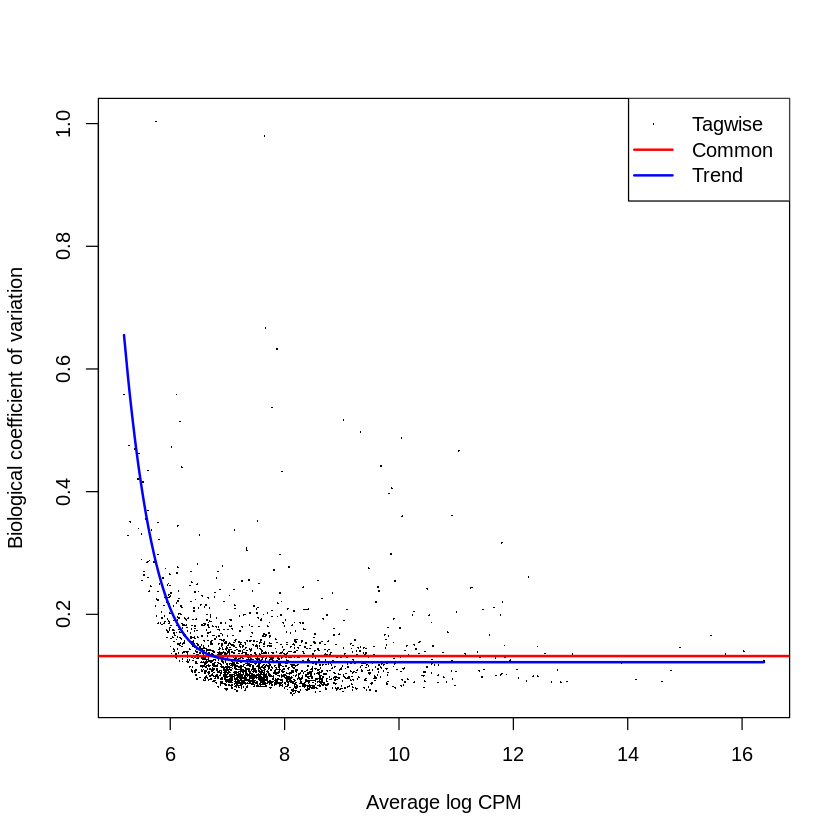

In [17]:
design.mat <- model.matrix(~ 0 + d$samples$group)
colnames(design.mat) <- levels(d$samples$group)
d2 <- estimateGLMCommonDisp(d,design.mat)
d2 <- estimateGLMTrendedDisp(d2,design.mat, method="power")
# You can change method to "auto", "bin.spline", "power", "spline", "bin.loess".
# The default is "auto" which chooses "bin.spline" when > 200 tags and "power" otherwise.
d2 <- estimateGLMTagwiseDisp(d2,design.mat)
plotBCV(d2)

In [33]:
WT15R_vs_WT10R <- exactTest(d1, pair=c(1,2)) # compare groups 1 and 2
WT20R_vs_WT10R <- exactTest(d1, pair=c(1,3)) # compare groups 1 and 3
WT25R_vs_WT10R <- exactTest(d1, pair=c(1,4)) # compare groups 1 and 4
WT30R_vs_WT10R <- exactTest(d1, pair=c(1,5)) # compare groups 1 and 5


# topTags(WT15R_vs_WT10R, n=10)

In [34]:
de1 <- decideTestsDGE(WT15R_vs_WT10R, adjust.method="fdr", p.value=0.05)
summary(de1)
# match.arg(method): 'arg' should be one of “holm”, “hochberg”, “hommel”, “bonferroni”, “BH”, “BY”, “fdr”, “none”

       WT15-WT10
Down         702
NotSig       691
Up           708

In [35]:
de2 <- decideTestsDGE(WT20R_vs_WT10R, adjust.method="fdr", p.value=0.05)
summary(de2)

       WT20-WT10
Down        1050
NotSig       273
Up           778

de3 <- decideTestsDGE(WT25R_vs_WT10R, adjust.method="fdr", p.value=0.05)
summary(de3)

In [36]:
de4 <- decideTestsDGE(WT30R_vs_WT10R, adjust.method="fdr", p.value=0.05)
summary(de4)


       WT30-WT10
Down         945
NotSig       218
Up           938

In [38]:
tt1<-topTags(WT15R_vs_WT10R,n =Inf)
tt2<-topTags(WT20R_vs_WT10R,n =Inf)
tt3<-topTags(WT25R_vs_WT10R,n =Inf)
tt4<-topTags(WT30R_vs_WT10R,n =Inf)
# save the results to a file in folder "results"
write.table(tt1, file="results/WT15R_vs_WT10R.csv", sep=",", quote=FALSE, row.names=TRUE)
write.table(tt2, file="results/WT20R_vs_WT10R.csv", sep=",", quote=FALSE, row.names=TRUE)
write.table(tt3, file="results/WT25R_vs_WT10R.csv", sep=",", quote=FALSE, row.names=TRUE)
write.table(tt4, file="results/WT30R_vs_WT10R.csv", sep=",", quote=FALSE, row.names=TRUE)

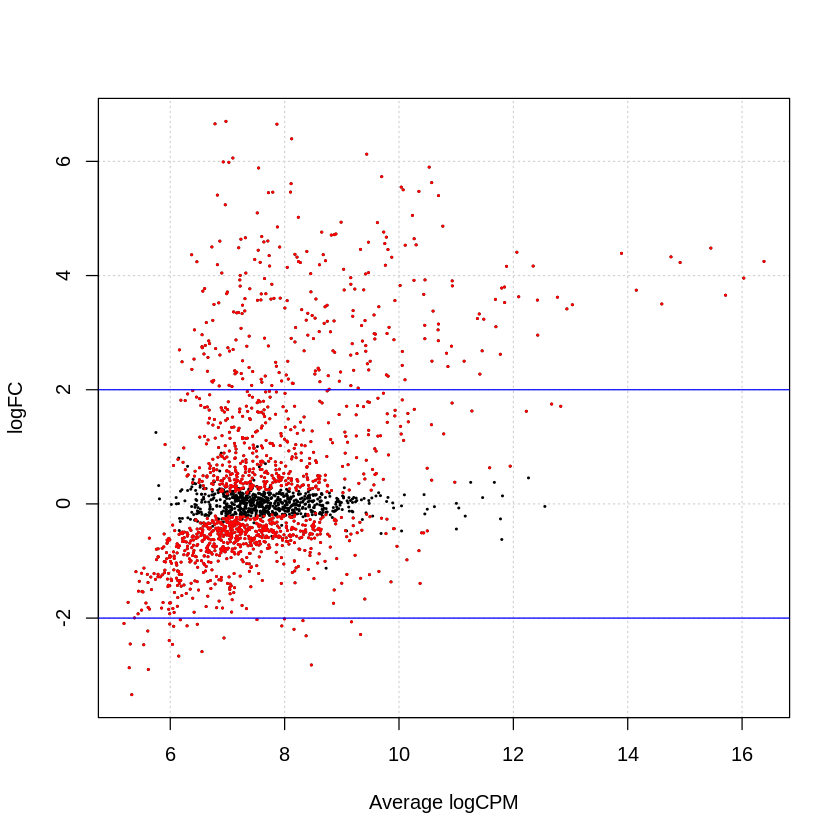

In [23]:
# differentially expressed tags from the naive method in d1
de1tags12 <- rownames(d1)[as.logical(de1)] 
plotSmear(WT15R_vs_WT10R, de.tags=de1tags12)
abline(h = c(-2, 2), col = "blue")

In [24]:
design.mat

,WT10,WT15,WT20,WT25,WT30,WT35
1,1,0,0,0,0,0
2,1,0,0,0,0,0
3,1,0,0,0,0,0
4,1,0,0,0,0,0
5,0,1,0,0,0,0
6,0,1,0,0,0,0
7,0,1,0,0,0,0
8,0,1,0,0,0,0
9,0,0,1,0,0,0
10,0,0,1,0,0,0


In [25]:
fit <- glmFit(d2, design.mat)
# compare (group 1 - group 2) to 0:
# this is equivalent to comparing group 1 to group 2
lrt12 <- glmLRT(fit, contrast=c(1,-1,0))
lrt13 <- glmLRT(fit, contrast=c(1,0,-1))
lrt23 <- glmLRT(fit, contrast=c(0,1,-1))
topTags(lrt12, n=10)

ERROR: Error in glmLRT(fit, contrast = c(1, -1, 0)): contrast vector of wrong length, should be equal to number of coefficients in the linear model.


In [26]:
#topTags(lrt13, n=10)
#topTags(lrt23, n=10)
de2 <- decideTestsDGE(lrt12, adjust.method="BH", p.value = 0.05)
de2tags12 <- rownames(d2)[as.logical(de2)]
plotSmear(lrt12, de.tags=de2tags12)
abline(h = c(-2, 2), col = "blue")

ERROR: Error in eval(expr, envir, enclos): object 'lrt12' not found
